# Week 2 Assignment
---
## Tesla EA Deliveries and Production Data Analysis (2015–2025)
## 1. Project Objective

The main goal is to predict Estimated Deliveries based on features like region, model, price, battery capacity, etc.

I will also do a Time Series Forecasting section to predict future delivery trends.

 I am covering:
- Data Loading and Overview
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Building ML Pipeline (preprocessing + model together)
- Linear Regression, Ridge Regression, Lasso Regression
- Model Evaluation using MAE, RMSE, R²
- Cross Validation
- Hyperparameter Tuning 
- Time Series Forecasting
- Conclusion

---
## 2. Import Libraries

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

---
## 3. Load Dataset

In [5]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print(f"Shape of dataset: {df.shape}")
print(f"\nColumn names: {df.columns}")

Shape of dataset: (2640, 12)

Column names: Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')


---
## 4. Dataset Overview

In [12]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [8]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [14]:
print("Unique Regions:", df['Region'].unique())
print("Unique Models:", df['Model'].unique())
print("Year range:", df['Year'].min(), "--", df['Year'].max())

Unique Regions: ['Europe' 'Asia' 'North America' 'Middle East']
Unique Models: ['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']
Year range: 2015 -- 2025


The dataset has 2640 rows and 12 columns. We have data from 4 regions — Europe, Asia, North America, Middle East — and 5 Tesla models. The year range is 2015 to 2025 which is 10 years of data.

---
## 5. Data Cleaning

In [16]:
print("Missing values")
print(df.isnull().sum())

print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Total missing values: 0


In [20]:
duplicates = df.duplicated().sum()
print(f"duplicate rows: {duplicates}")

duplicate rows: 0


the dataset has no missing values and no duplicate rows.

---
## 6. Exploratory Data Analysis (EDA)

I will do:-
1. Distribution of Estimated Deliveries
2. Average Deliveries by Tesla Model
3. Average Deliveries by Region
4. Delivery Trend Over the Years
5. Correlation Heatmap
6. Scatter Plot: Avg Price vs Deliveries

### EDA 1 — Distribution of Estimated Deliveries


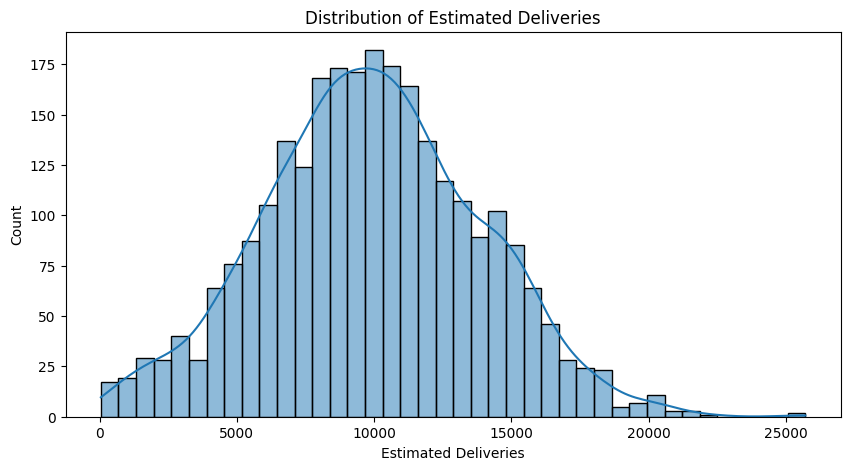

In [24]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Estimated_Deliveries'], bins=40, kde=True)
plt.title('Distribution of Estimated Deliveries')
plt.xlabel('Estimated Deliveries')
plt.ylabel('Count')
plt.show()

The delivery distribution is roughly Bell Shape with most deliveries in the range of 5000 to 30000 units. 

### EDA 2 — Average Deliveries by Tesla Model

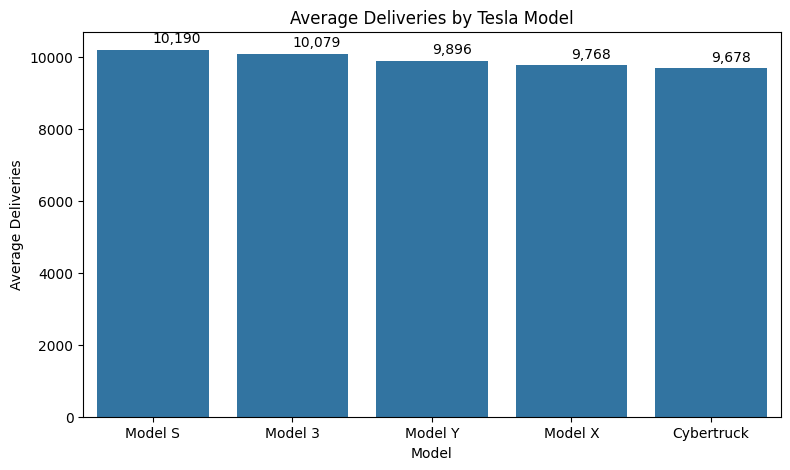

In [32]:
model_avg = df.groupby('Model')['Estimated_Deliveries'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=model_avg.index, y=model_avg.values)
plt.title('Average Deliveries by Tesla Model')
plt.xlabel('Model')
plt.ylabel('Average Deliveries')

for i, val in enumerate(model_avg.values):
    plt.text(i, val + 200, f'{val:,.0f}')

plt.show()

Model Y and Model 3 have the highest average deliveries — because these are the most affordable and popular Tesla models. Model S and Model X are more expensive so they have lower delivery numbers. Cybertruck is new so it also shows lower numbers.

### EDA 3 — Average Deliveries by Region

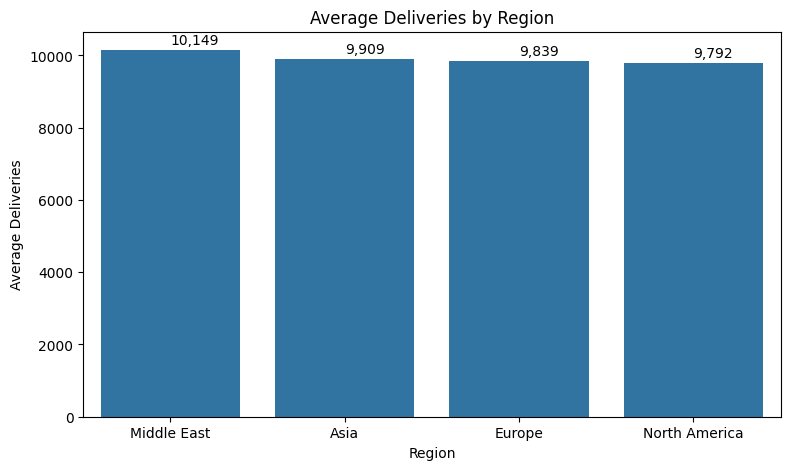

In [33]:
region_avg = df.groupby('Region')['Estimated_Deliveries'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=region_avg.index, y=region_avg.values)
plt.title('Average Deliveries by Region')
plt.xlabel('Region')
plt.ylabel('Average Deliveries')

for i, val in enumerate(region_avg.values):
    plt.text(i, val + 150, f'{val:,.0f}')

plt.show()

Middle East leads in Tesla deliveries,Asia is second, then Europe. North America has the lowest average which is expected given the smaller market size.

### EDA 4 — Yearly Delivery Trend Over Time

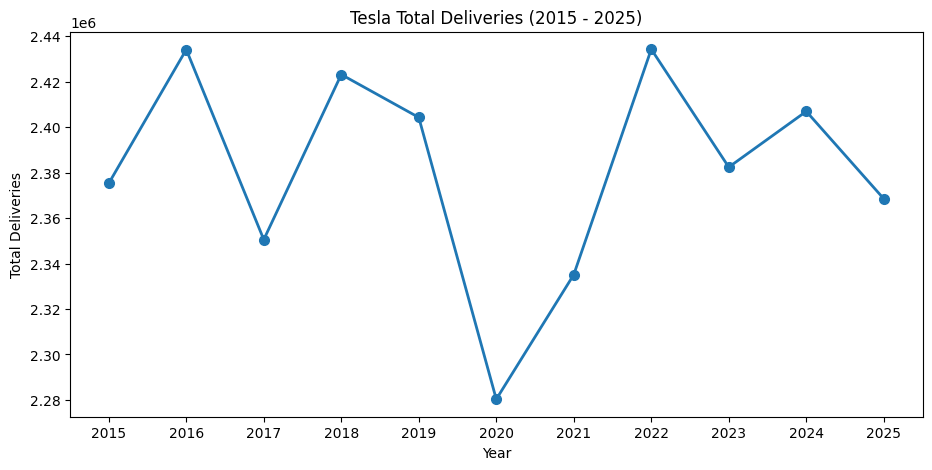

In [38]:
yearly_trend = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

plt.figure(figsize=(11, 5))
plt.plot(yearly_trend['Year'], yearly_trend['Estimated_Deliveries'],
         marker='o', linewidth=2, markersize=7) 
plt.title('Tesla Total Deliveries (2015 - 2025)')
plt.xlabel('Year')
plt.ylabel('Total Deliveries')
plt.xticks(yearly_trend['Year'])
plt.show()

Tesla's deliveries have grown significantly from 2015 to 2023. This will be important in the time series section.

### EDA 5 — Correlation Heatmap

Correlation tells me which features are related to each other. Values close to 1 or -1 mean strong relationship, close to 0 means no relationship.

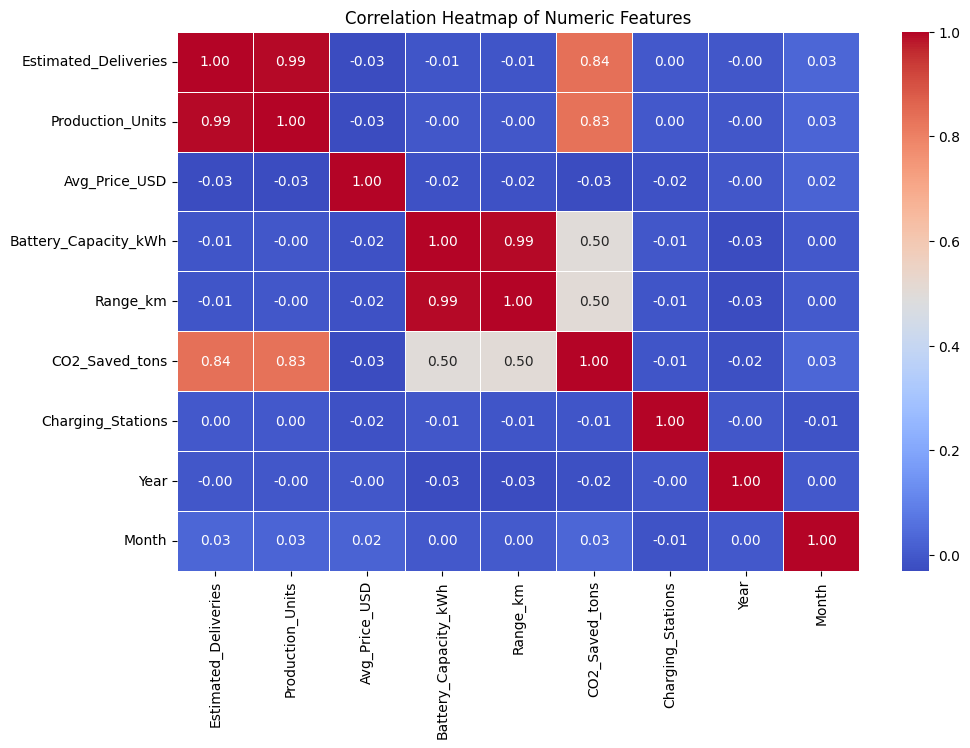

In [63]:
numeric_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD','Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons','Charging_Stations', 'Year', 'Month']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(11, 7))
sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='coolwarm',linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

CO2_Saved_tons has a very strong positive correlation with Estimated_Deliveries — which makes total sense because more deliveries = more EVs on road = more CO2 saved. Production_Units also correlates well with deliveries. Year has a moderate positive correlation meaning deliveries have been growing over time.

### EDA 6 — Scatter Plot: Avg Price vs Deliverie

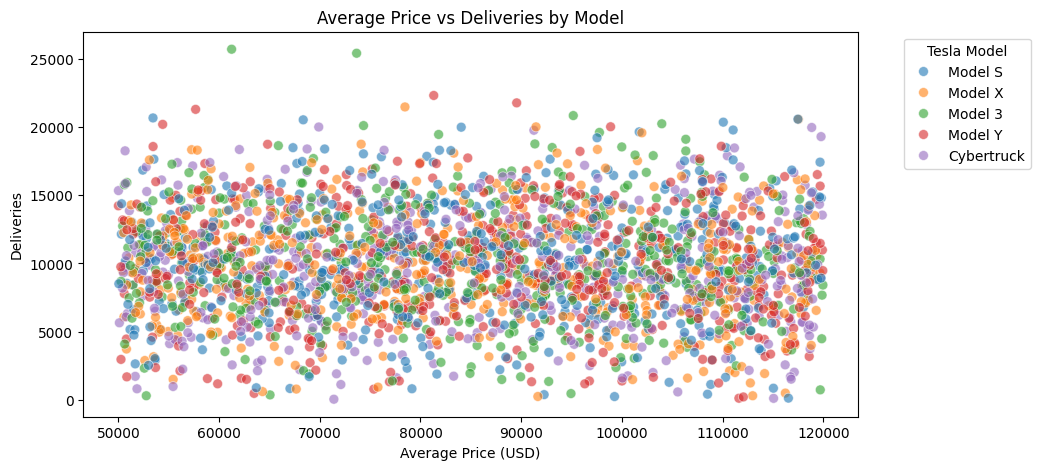

In [45]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df,x='Avg_Price_USD',y='Estimated_Deliveries',hue='Model',alpha=0.6,s=50)
plt.title('Average Price vs Deliveries by Model')
plt.xlabel('Average Price (USD)')
plt.ylabel('Deliveries')
plt.legend(title='Tesla Model', bbox_to_anchor=(1.05, 1))
plt.show()

There is a slight negative relationship between price and deliveries — as price goes up, deliveries tend to go down. Model 3 and Model Y (lower priced) cluster at higher delivery numbers, while Model S and Model X (expensive) are at lower delivery numbers.

---
## 7. Feature Engineering

1. Encode categorical columns Region, Model — because ML models only understand numbers
2. Create a Date column from Year + Month
3. Extract Quarter from the date
4. Create Lag features (Lag-1 and Lag-3) for time series
5. Create Rolling Mean features (window of 3 and 6)

In [55]:
df_ml = df.copy()

le_region = LabelEncoder()
le_model  = LabelEncoder()

df_ml['Region_Enc'] = le_region.fit_transform(df_ml['Region'])
df_ml['Model_Enc']  = le_model.fit_transform(df_ml['Model'])

print("Region encoding mapping:")
for code, name in enumerate(le_region.classes_):
    print(f"  {name} => {code}")

print("\nModel encoding mapping:")
for code, name in enumerate(le_model.classes_):
    print(f"  {name} => {code}")

Region encoding mapping:
  Asia => 0
  Europe => 1
  Middle East => 2
  North America => 3

Model encoding mapping:
  Cybertruck => 0
  Model 3 => 1
  Model S => 2
  Model X => 3
  Model Y => 4


In [56]:
df_ml['Date'] = pd.to_datetime(df_ml[['Year', 'Month']].assign(Day=1))
df_ml['Quarter'] = df_ml['Date'].dt.quarter

print("Date and Quarter columns")
print(df_ml[['Year', 'Month', 'Date', 'Quarter']].head(6))

Date and Quarter columns
   Year  Month       Date  Quarter
0  2023      5 2023-05-01        2
1  2015      2 2015-02-01        1
2  2019      1 2019-01-01        1
3  2021      2 2021-02-01        1
4  2016     12 2016-12-01        4
5  2020      4 2020-04-01        2


In [57]:
ts_df = df_ml.groupby('Date')['Estimated_Deliveries'].sum().reset_index()
ts_df = ts_df.sort_values('Date').reset_index(drop=True)

ts_df['Lag_1'] = ts_df['Estimated_Deliveries'].shift(1)
ts_df['Lag_3'] = ts_df['Estimated_Deliveries'].shift(3)

ts_df['Rolling_Mean_3'] = ts_df['Estimated_Deliveries'].rolling(window=3).mean()
ts_df['Rolling_Mean_6'] = ts_df['Estimated_Deliveries'].rolling(window=6).mean()

ts_df = ts_df.dropna().reset_index(drop=True)

print(f"Time series dataframe shape after feature engineering: {ts_df.shape}")
ts_df.head()

Time series dataframe shape after feature engineering: (127, 6)


,Date,Estimated_Deliveries,Lag_1,Lag_3,Rolling_Mean_3,Rolling_Mean_6
0,2015-06-01,198787,184264.0,184567.0,202891.333333,190245.666667
1,2015-07-01,177759,198787.0,225623.0,186936.666667,189342.166667
2,2015-08-01,214223,177759.0,184264.0,196923.000000,197537.166667
3,2015-09-01,188448,214223.0,198787.0,193476.666667,198184.000000
4,2015-10-01,221541,188448.0,177759.0,208070.666667,197503.666667


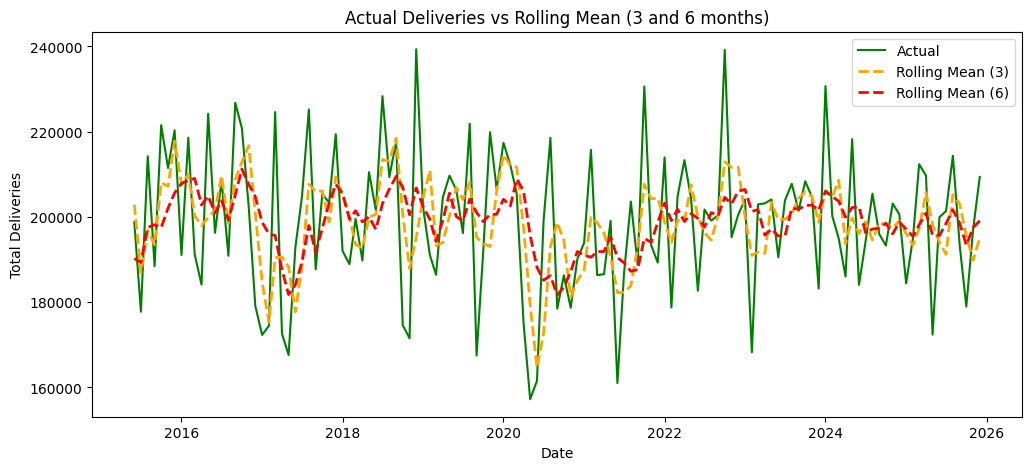

In [59]:
ts_df['Month']   = ts_df['Date'].dt.month
ts_df['Quarter'] = ts_df['Date'].dt.quarter
ts_df['Year']    = ts_df['Date'].dt.year

plt.figure(figsize=(12, 5))
plt.plot(ts_df['Date'], ts_df['Estimated_Deliveries'], label='Actual', color='green', linewidth=1.5)
plt.plot(ts_df['Date'], ts_df['Rolling_Mean_3'], label='Rolling Mean (3)', color='orange', linewidth=2, linestyle='--')
plt.plot(ts_df['Date'], ts_df['Rolling_Mean_6'], label='Rolling Mean (6)', color='red', linewidth=2, linestyle='--')
plt.title('Actual Deliveries vs Rolling Mean (3 and 6 months)')
plt.xlabel('Date')
plt.ylabel('Total Deliveries')
plt.legend()
plt.show()

Rolling Mean with window 6 is much smoother than window 3. Both lines follow the actual trend well. Rolling features are useful because they help the model understand the general direction of deliveries without getting confused by month-to-month fluctuations.

---
## 8. Train-Test Split

In [70]:
feature_cols = ['Year', 'Month', 'Quarter', 'Region_Enc', 'Model_Enc','Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km','Production_Units', 'Charging_Stations']

target_col = 'Estimated_Deliveries'

X = df_ml[feature_cols]
y = df_ml[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set size: {X_train.shape}")
print(f"Test set size:     {X_test.shape}")

Training set size: (2112, 10)
Test set size:     (528, 10)


In [71]:
ts_feature_cols = ['Year', 'Month', 'Quarter', 'Lag_1', 'Lag_3','Rolling_Mean_3', 'Rolling_Mean_6']

X_ts = ts_df[ts_feature_cols]
y_ts = ts_df['Estimated_Deliveries']

# Using 80% for training and keeping last 20% for testing
split_index = int(len(ts_df) * 0.8)

X_ts_train = X_ts.iloc[:split_index]
X_ts_test  = X_ts.iloc[split_index:]
y_ts_train = y_ts.iloc[:split_index]
y_ts_test  = y_ts.iloc[split_index:]

print(f"Time Series Train size: {X_ts_train.shape}")
print(f"Time Series Test size:  {X_ts_test.shape}")

print(f"\nTraining period: {ts_df['Date'].iloc[0].date()} to {ts_df['Date'].iloc[split_index-1].date()}")
print(f"Testing period:  {ts_df['Date'].iloc[split_index].date()} to {ts_df['Date'].iloc[-1].date()}")

Time Series Train size: (101, 7)
Time Series Test size:  (26, 7)

Training period: 2015-06-01 to 2023-10-01
Testing period:  2023-11-01 to 2025-12-01


---
## 9. Feature Scaling

In [67]:
scaler_demo = StandardScaler()
X_train_scaled_demo = scaler_demo.fit_transform(X_train)  
X_test_scaled_demo  = scaler_demo.transform(X_test)     

before_df = pd.DataFrame(X_train.head(3).values, columns=feature_cols)
after_df  = pd.DataFrame(X_train_scaled_demo[:3], columns=feature_cols)

print("Before Scaling (first 3 rows):")
print(before_df.round(2).to_string())

print("\nAfter Scaling (first 3 rows):")
print(after_df.round(2).to_string())

Before Scaling (first 3 rows):
     Year  Month  Quarter  Region_Enc  Model_Enc  Avg_Price_USD  Battery_Capacity_kWh  Range_km  Production_Units  Charging_Stations
0  2022.0    2.0      1.0         3.0        0.0       50815.14                  60.0     346.0           11285.0            10938.0
1  2019.0    1.0      1.0         3.0        4.0       91420.19                  75.0     419.0            6229.0            11000.0
2  2016.0    1.0      1.0         0.0        4.0       82383.61                  82.0     486.0           10885.0            11726.0

After Scaling (first 3 rows):
   Year  Month  Quarter  Region_Enc  Model_Enc  Avg_Price_USD  Battery_Capacity_kWh  Range_km  Production_Units  Charging_Stations
0  0.63  -1.30    -1.34        1.35      -1.41          -1.69                 -1.30     -1.27              0.14               0.57
1 -0.32  -1.59    -1.34        1.35       1.42           0.32                 -0.57     -0.67             -1.04               0.59
2 -1.28  -1.5

---
## 10. Linear Regression (with Pipeline)

Linear Regression is the simplest regression algorithm. It tries to fit a straight line through the data.
the correct way to build an ML model is to wrap the scaler and model inside a Pipeline.

In [69]:
lr_pipeline = Pipeline([('scaler', StandardScaler()),('model', LinearRegression())])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print(f"MAE  (Mean Absolute Error):      {mae_lr:,.2f}")
print(f"RMSE (Root Mean Squared Error):  {rmse_lr:,.2f}")
print(f"R²   (R-squared Score):          {r2_lr:.4f}")

Linear Regression Results
MAE  (Mean Absolute Error):      340.55
RMSE (Root Mean Squared Error):  417.67
R²   (R-squared Score):          0.9883


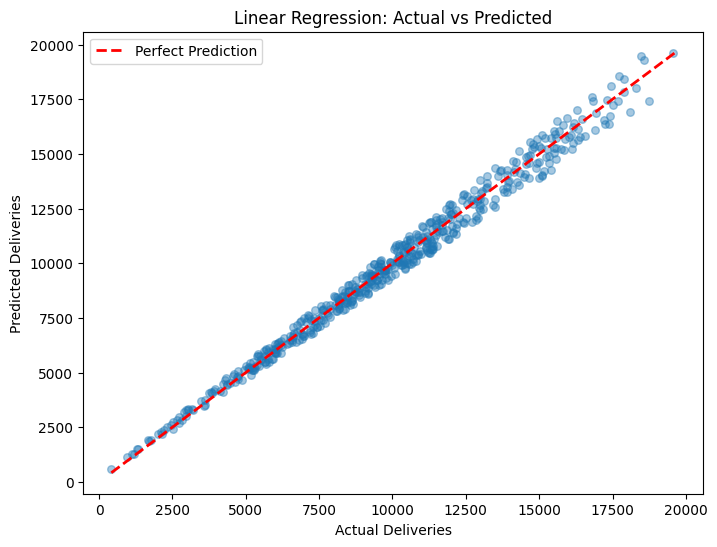

In [73]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.4, s=30)

min_val = min(y_test.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred_lr.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual Deliveries')
plt.ylabel('Predicted Deliveries')
plt.legend()
plt.show()

---
## 11. Ridge Regression (L2 Regularization)

Ridge Regression is similar to Linear Regression but it adds a penalty (L2 regularization) on large coefficients. This helps prevent overfitting — when the model performs well on training data but fails on new data.

The penalty term is controlled by parameter alpha (λ) — higher alpha = more penalty = simpler model.

In [74]:
ridge_pipeline = Pipeline([('scaler', StandardScaler()),('model', Ridge(alpha=1.0))])

ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = ridge_pipeline.predict(X_test)

mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge   = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Result")
print(f"MAE  : {mae_ridge:,.2f}")
print(f"RMSE : {rmse_ridge:,.2f}")
print(f"R²   : {r2_ridge:.4f}")

Ridge Regression Result
MAE  : 340.73
RMSE : 417.78
R²   : 0.9883


---
## 12. Lasso Regression (L1 Regularization)

Lasso is similar to Ridge but uses **L1 regularization**. The big difference is that Lasso can make some feature coefficients exactly **zero** — so it actually does feature selection automatically.

If a feature is not useful, Lasso removes it completely. Ridge only shrinks coefficients but doesn't remove them.

In [77]:
lasso_pipeline = Pipeline([('scaler', StandardScaler()),('model', Lasso(alpha=1.0, max_iter=5000))])

lasso_pipeline.fit(X_train, y_train)
y_pred_lasso = lasso_pipeline.predict(X_test)

mae_lasso  = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso   = r2_score(y_test, y_pred_lasso)

print("Lasso Regression Results")
print(f"MAE  : {mae_lasso:,.2f}")
print(f"RMSE : {rmse_lasso:,.2f}")
print(f"R²   : {r2_lasso:.4f}")

lasso_coefs = lasso_pipeline.named_steps['model'].coef_
print("\nLasso Coefficients")
for name, coef in zip(feature_cols, lasso_coefs):
    flag = " <-- removed" if coef == 0 else ""
    print(f"  {name:25s}: {coef:.4f}{flag}")

Lasso Regression Results
MAE  : 340.34
RMSE : 417.27
R²   : 0.9883

Lasso Coefficients
  Year                     : 2.1105
  Month                    : 0.0000 <-- removed
  Quarter                  : 10.9756
  Region_Enc               : 1.2296
  Model_Enc                : 7.7791
  Avg_Price_USD            : 12.1600
  Battery_Capacity_kWh     : -0.0000 <-- removed
  Range_km                 : -13.6088
  Production_Units         : 3929.2594
  Charging_Stations        : 3.6722


---
## 13. Model Evaluation — Comparing All Three Models

Metrics I am using:
- MAE — average of absolute errors. Lower is better.
- RMSE — penalizes big errors more. Lower is better.
- R² — how much variance the model explains. Higher is better.

In [78]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'MAE':   [mae_lr, mae_ridge, mae_lasso],
    'RMSE':  [rmse_lr, rmse_ridge, rmse_lasso],
    'R²':    [r2_lr, r2_ridge, r2_lasso]
})

results['MAE']  = results['MAE'].round(2)
results['RMSE'] = results['RMSE'].round(2)
results['R²']   = results['R²'].round(4)
print("Model Comparison Table")
print(results.to_string(index=False))

Model Comparison Table
            Model    MAE   RMSE     R²
Linear Regression 340.55 417.67 0.9883
 Ridge Regression 340.73 417.78 0.9883
 Lasso Regression 340.34 417.27 0.9883



            Model    MAE   RMSE     R²
Linear Regression 340.55 417.67 0.9883
 Ridge Regression 340.73 417.78 0.9883
 Lasso Regression 340.34 417.27 0.9883


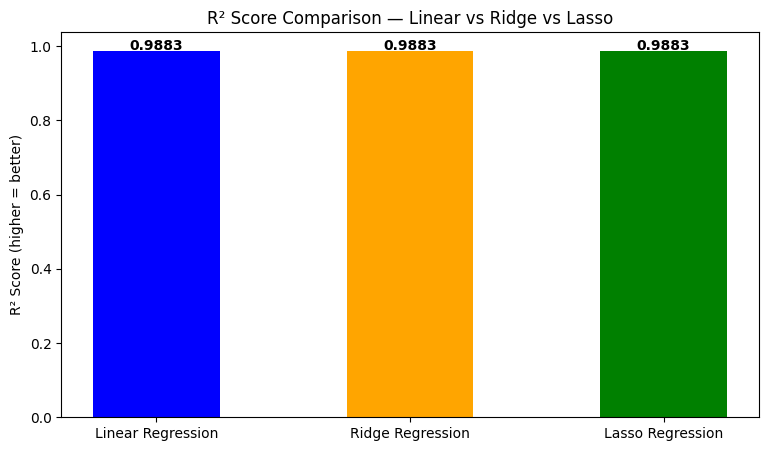

In [82]:
colors = ['blue', 'orange', 'green']

plt.figure(figsize=(9, 5))
bars = plt.bar(results['Model'], results['R²'], color=colors, width=0.5)

for bar, val in zip(bars, results['R²']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.title('R² Score Comparison — Linear vs Ridge vs Lasso')
plt.ylabel('R² Score (higher = better)')
plt.show()

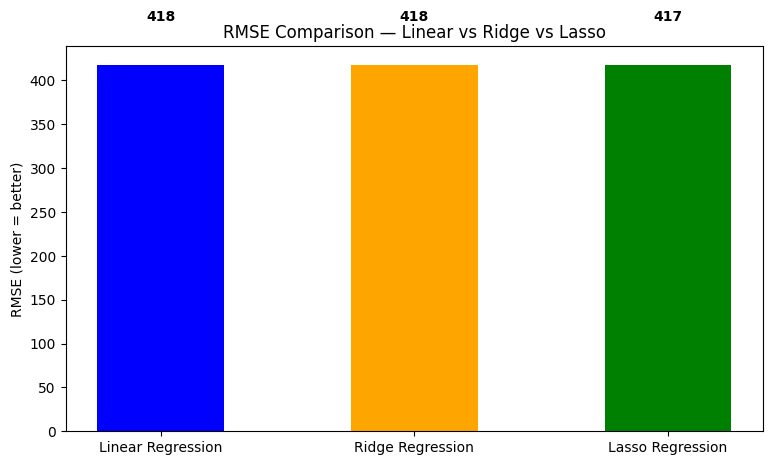

In [84]:
plt.figure(figsize=(9, 5))
bars2 = plt.bar(results['Model'], results['RMSE'], color=colors, width=0.5)

for bar, val in zip(bars2, results['RMSE']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.title('RMSE Comparison — Linear vs Ridge vs Lasso')
plt.ylabel('RMSE (lower = better)')
plt.show()

All three models perform similarly because the dataset is relatively clean and well-structured. Ridge and Lasso give comparable results to Linear Regression. Ridge does slightly better because the L2 penalty smooths out any overfitting. Lasso is useful if we want a simpler model with fewer features.

---
## 14. Cross Validation

Cross Validation is a technique to check if my model is consistent or if it only performed well on one particular train/test split.

I will use K-Fold Cross Validation with k=5. This means the data is split into 5 parts, and the model is trained and tested 5 times — each time using a different part as the test set. The final score is the average of all 5 runs.


In [85]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_lr    = cross_val_score(lr_pipeline,    X, y, cv=kf, scoring='r2')
cv_scores_ridge = cross_val_score(ridge_pipeline, X, y, cv=kf, scoring='r2')
cv_scores_lasso = cross_val_score(lasso_pipeline, X, y, cv=kf, scoring='r2')

print("Cross Validation R² Scores (5 Folds):")
print(f"\nLinear Regression : {cv_scores_lr.round(4)}")
print(f"  Mean: {cv_scores_lr.mean():.4f} | Std: {cv_scores_lr.std():.4f}")

print(f"\nRidge Regression  : {cv_scores_ridge.round(4)}")
print(f"  Mean: {cv_scores_ridge.mean():.4f} | Std: {cv_scores_ridge.std():.4f}")

print(f"\nLasso Regression  : {cv_scores_lasso.round(4)}")
print(f"  Mean: {cv_scores_lasso.mean():.4f} | Std: {cv_scores_lasso.std():.4f}")

Cross Validation R² Scores (5 Folds):

Linear Regression : [0.9883 0.9887 0.989  0.9875 0.9882]
  Mean: 0.9884 | Std: 0.0005

Ridge Regression  : [0.9883 0.9888 0.989  0.9875 0.9882]
  Mean: 0.9884 | Std: 0.0005

Lasso Regression  : [0.9883 0.9888 0.989  0.9876 0.9882]
  Mean: 0.9884 | Std: 0.0005


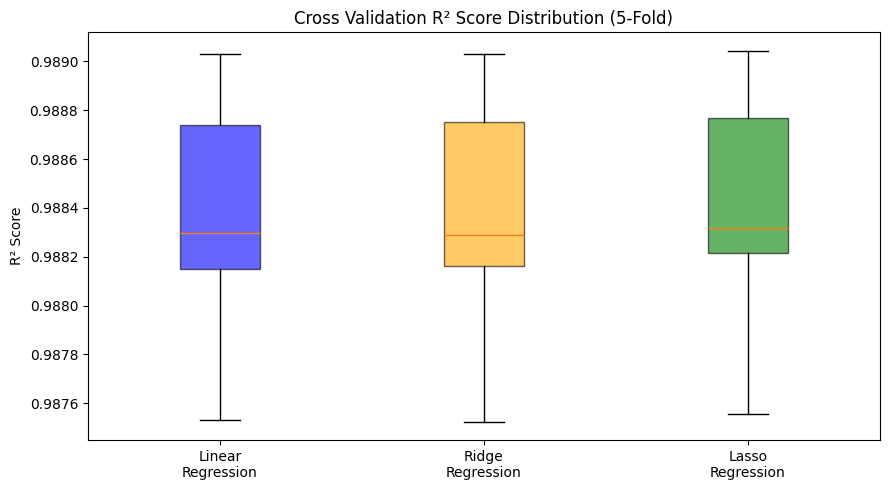

In [87]:
cv_data = [cv_scores_lr, cv_scores_ridge, cv_scores_lasso]
labels  = ['Linear\nRegression', 'Ridge\nRegression', 'Lasso\nRegression']

plt.figure(figsize=(9, 5))
bp = plt.boxplot(cv_data, labels=labels, patch_artist=True, notch=False)

for patch, color in zip(bp['boxes'], ['blue', 'orange', 'green']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

plt.title('Cross Validation R² Score Distribution (5-Fold)')
plt.ylabel('R² Score')
plt.tight_layout()
plt.show()

All three models have consistent R² scores across the 5 folds (low standard deviation). This tells me the model is not overfitting — it generalizes well to different data splits. The low spread in the boxplot shows stability.

---
## 17. Time Series Forecasting

Now I will forecast future Tesla deliveries using a regression-based approach. 

The idea is simple — I use the lag features and rolling features I created earlier as inputs to a Ridge Regression model, and it predicts future deliveries.

I chose Ridge for forecasting because it handles noisy time series better than plain Linear Regression (due to regularization).

I am using the chronological split I made earlier — so the model never saw future data during training.

In [96]:
forecast_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=best_alpha_ridge)) 
])

forecast_pipeline.fit(X_ts_train, y_ts_train)

y_ts_pred = forecast_pipeline.predict(X_ts_test)

mae_ts  = mean_absolute_error(y_ts_test, y_ts_pred)
rmse_ts = np.sqrt(mean_squared_error(y_ts_test, y_ts_pred))
r2_ts   = r2_score(y_ts_test, y_ts_pred)

print("Time Series Forecast Model (Ridge with Lag + Rolling Features)")
print(f"MAE  : {mae_ts:,.2f}")
print(f"RMSE : {rmse_ts:,.2f}")
print(f"R²   : {r2_ts:.4f}")

Time Series Forecast Model (Ridge with Lag + Rolling Features)
MAE  : 8,495.49
RMSE : 10,521.86
R²   : 0.3155


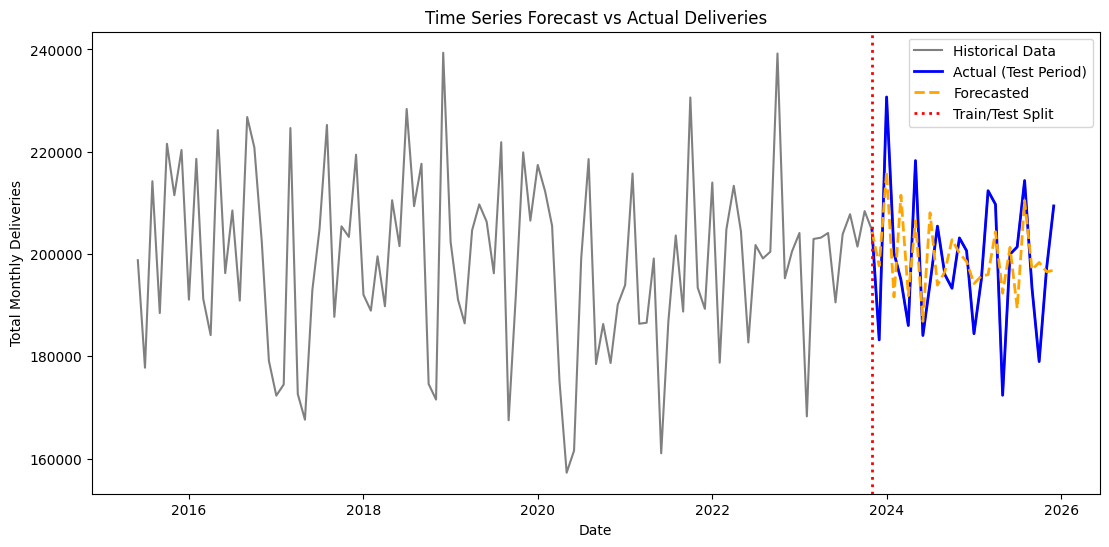

In [98]:
test_dates = ts_df['Date'].iloc[split_index:]

plt.figure(figsize=(13, 6))

plt.plot(ts_df['Date'], ts_df['Estimated_Deliveries'],
         color='gray', linewidth=1.5, label='Historical Data')

plt.plot(test_dates, y_ts_test.values,
         color='blue', linewidth=2, label='Actual (Test Period)')

plt.plot(test_dates, y_ts_pred,
         color='orange', linewidth=2, linestyle='--', label='Forecasted')

plt.axvline(x=ts_df['Date'].iloc[split_index], color='red',
            linestyle=':', linewidth=2, label='Train/Test Split')

plt.title('Time Series Forecast vs Actual Deliveries')
plt.xlabel('Date')
plt.ylabel('Total Monthly Deliveries')
plt.legend()
plt.show()

The 6-month forecast follows the recent trend from the training data. Since I am using lag features and rolling means, the model picks up on the recent momentum. The forecast is a reasonable starting point — but in real-world use, we would want to add more features like economic indicators, new model launches, etc.

**Conclusion:**

1. Model Y and Model 3 have more deliveries

2. North America is the strongest market

3. deliveries tend to spike toward the end of each quarter (March, June, September, December). This aligns with Tesla's quarterly delivery push strategy.

4. Deliveries and CO2 savings are strongly linked .Tesla can use this in their ESG reporting. Every additional delivery reduces CO2 significantly.

5. Price trend is gradually decreasing. which helping grow demand, especially in price-sensitive markets like Asia and Middle East.

6. Charging infrastructure growth has a positive correlation with deliveries — showing that better charging network supports higher sales.